Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
%%capture
!pip install watermark
!pip install torchinfo datasets

In [2]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.8.0+cu126



# Single-Layer Recurrent Neural Network (RNN) Classifier on IMDB 

The network in this notebook is an implementation of a simple RNN **[1]** on IMDB reviews **[5]**.

**Network Architecture:**

The Elman RNN (or Simple RNN) replaced the "static" assumption of standard Feed-forward networks by introducing a **Hidden State ($h_t$)** **[4]**. This creates a feedback loop where the network's output at one time step becomes an input for the next, allowing the model to process sequences of variable length.


![RNN architecture](https://d2l.ai/_images/rnn.svg)

[Source](https://d2l.ai/chapter_recurrent-neural-networks/rnn.html)


---

### **Key Concepts of the `RNN` Architecture:**

1. **Hidden State Recurrence ($h_t$):** Unlike `NiN` or `ResNet` which only pass information forward, the RNN maintains a "hidden state" that acts as the network's internal memory. At each time step $t$, the current input $x_t$ is combined with the previous hidden state $h_{t-1}$ to produce a new $h_t$. This allows the model to capture temporal dependencies in text.<br><br>
2. **Shared Weights Across Time:** In a CNN, weights are shared across spatial locations (pixels). In an RNN, the same weights ($W_{ih}$ and $W_{hh}$) are reused at **every single time step**. This drastically reduces the parameter count compared to a massive Flatten layer and allows the model to generalize across different sentence lengths.<br><br>
3. **Many-to-One Mapping:** For classification tasks like IMDB (Sentiment) or AG News (Topic), we process the entire sequence but only use the **final hidden state** for the prediction. This final state acts as a "neural summary" of the entire sentence, similar to how **Global Average Pooling** summarizes a feature map.

---
### **Improvements of `RNN` over Deep `CNN`:**

1. **Temporal Dependency Modeling:** Standard CNNs (like `VGG` or `ResNet`) assume that inputs are independent of each other. While a CNN is excellent at extracting spatial features (like a nose in a face), it cannot inherently understand that "not" at the beginning of a sentence changes the meaning of "good" at the end. `RNNs` introduce **Recurrence**, allowing the network to build a "contextual summary" as it reads through a sequence.<br><br>
2. **Variable-Length Processing:** Traditional deep CNNs require a fixed-size input (e.g., $224\times224$ pixels). If an image is larger or smaller, it must be resized. `RNNs` are architecturally flexible; because the same weights are applied at every step, the model can process a 5-word tweet or a 500-word review using the exact same number of parameters.<br><br>
3. **Parameter Efficiency for Sequences:** To capture long-range dependencies in a CNN, one would need a massive receptive field (very deep layers or huge kernels). An `RNN` achieves this "depth" through time. By reusing the same $W_{hh}$ (Hidden-to-Hidden) matrix, the model achieves a form of "infinite depth" in the temporal dimension without the explosive memory cost of the 4096-unit fully connected layers found in `AlexNet` or `VGG`.

---

### **Quick Comparison Table: CNN vs. RNN Architecture**

| Feature | CNN (NiN / ResNet / VGG) | Recurrent Neural Network (RNN) |
| :--- | :--- | :--- |
| **Primary Data Type** | Spatial (Images, Grids, Fixed-size) | **Sequential (Text, Audio, Time-series)** |
| **Input Relationship** | Assumes inputs are independent | **Assumes inputs are temporally dependent** |
| **Information Flow** | Feed-forward (Layer $L \to L+1$) | **Recurrent (Step $T-1 \to T$)** |
| **Weight Sharing** | Across **Space** (Kernel sliding) | Across **Time** (Step-wise recurrence) |
| **Memory Mechanism** | No internal memory (Static) | **Hidden State ($h_t$)** (Internal memory) |
| **Input Constraints** | Requires fixed-size (Resizing/Padding) | **Handles variable-length sequences** |
| **Pattern Recognition** | Extracts local features (Edges, Shapes) | Extracts **Contextual context** (Grammar, Logic) |
| **Downsampling** | Max Pooling / Global Average Pooling | **Final Hidden State** (Sequence summary) |

<br><br>

**REFERENCES:**
1. Elman, Jeffrey L. ["Finding Structure in Time."](https://onlinelibrary.wiley.com/doi/abs/10.1207/s15516709cog1402_1) Cognitive Science, 1990.
2. PyTorch. ["Recurrent Layers: nn.RNN."](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html) *PyTorch Documentation*, 2026.
3. Zhang, Aston, et al. ["Recurrent Neural Networks (Chapter 9.1)."](https://d2l.ai/chapter_recurrent-neural-networks/rnn.html) _Dive into Deep Learning_. Cambridge University Press, 2023.
4. Raschka, Sebastian. ["L15: Introduction to recurrent neural networks."](https://sebastianraschka.com/blog/2021/dl-course.html#l15-introduction-to-recurrent-neural-networks) *Introduction to Deep Learning*, 2021. [[slides](https://sebastianraschka.com/pdf/lecture-notes/stat453ss21/L15_intro-rnn__slides.pdf)]
5. Maas, Andrew L., et al. ["Learning Word Vectors for Sentiment Analysis."](https://ai.stanford.edu/~amaas/papers/wv_sent_analysis.pdf) *Proceedings of the 49th Annual Meeting of the Association for Computational Linguistics: Human Language Technologies*, 2011.
6. Google. (2026). ["Gemini 3 Flash"](https://gemini.google.com/) [Large language model]. Google AI.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, DatasetDict
from collections import Counter

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


# from torch.cuda.amp import GradScaler, autocast
from torch.amp import GradScaler, autocast
from torchinfo import summary

import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random
import re

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [4]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

---
# 0. Model Hyperparameters
---

In [5]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128 
LEARNING_RATE = 0.001
NUM_EPOCHS = 15
# NUM_CLASSES = 2   # [Positive, Negative]

# Vocabulary & Architecture
VOCABULARY_SIZE = 20000
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
# OUTPUT_DIM = 1

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


---
# 1. Data Preparation & Loading

---

In [6]:
# 1. Load Dataset 
DATASET_CONFIG = "imdb"  # Use "imdb", "ag_news", "amazon_reviews_multi", etc.
raw_datasets = load_dataset(DATASET_CONFIG)


# Split 10% of 'train' to create a 'validation' set (seed for reproducibility)
train_val_split = raw_datasets["train"].train_test_split(test_size=0.1, seed=RANDOM_SEED)

ds_splits = DatasetDict({
    'train': train_val_split['train'],
    'validation': train_val_split['test'], # The 10% we just carved out
    'test': raw_datasets['test']
})

print(ds_splits)

# ------------Robust Extraction of Class Names----------
dataset_label_features = raw_datasets['train'].features['label']

if hasattr(dataset_label_features, 'names'):
    class_names = dataset_label_features.names
    NUM_CLASSES = len(class_names)
else:
    # Fallback for datasets that don't have metadata names
    NUM_CLASSES = len(set(raw_datasets['train']['label']))
    class_names = [f"Class {i}" for i in range(NUM_CLASSES)]

# ----------Auto-detect Binary vs Multi-class-------------
# Note: For IMDB, NUM_CLASSES is 2. For AG News, it's 4.
# IS_BINARY = True if NUM_CLASSES <= 2 else False

is_imdb = DATASET_CONFIG.lower() == "imdb"
IS_BINARY = True if is_imdb else False


# --------DYNAMIC HYPERPARAMETERS ----------------------
# If binary, output layer needs 1 node (for Sigmoid: BCEWithLogitsLoss); else num_classes (for Softmax)
MODEL_OUTPUT_SIZE = 1 if IS_BINARY else NUM_CLASSES

print(f"\n[ROBUST CONFIG COMPLETE]")
print(f"Dataset: {DATASET_CONFIG} | Num of Classes : {NUM_CLASSES} | Classes: {class_names}")
print(f"Is Binary: {IS_BINARY} | Model Output Nodes: {MODEL_OUTPUT_SIZE}")

# 2. Build Vocabulary (From Scratch Logic)
tokenizer = lambda text: re.findall(r'\w+', text.lower())
word_counts = Counter()

# Important: We only iterate over ds_splits['train']
for text in ds_splits['train']['text']:
    word_counts.update(tokenizer(text))

# Filter rare words and create mapping: : <PAD>=0, <UNK>=1, then top 20k words
vocab = {word: i + 2 for i, (word, count) in enumerate(word_counts.most_common(VOCABULARY_SIZE))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

print(f"Vocab size: {len(vocab)}")
VOCAB_SIZE = len(vocab)

# 3. Custom Dataset Class 
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_split, vocab, max_len=256):
        self.data = dataset_split
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        tokens = tokenizer(item['text'])
        
        # Numericalize
        ids = [self.vocab.get(t, 1) for t in tokens]
        
        # Manual Padding/Truncating
        curr_len = len(ids)
        if curr_len < self.max_len:
            ids += [0] * (self.max_len - curr_len)
        else:
            ids = ids[:self.max_len]
            curr_len = self.max_len
            
        # Label handling (float for binary, long for multi-class)
        # For AG News, we'd use dtype=torch.long
        label = torch.tensor(item['label'], dtype=torch.float)
            
        return torch.tensor(ids), label, torch.tensor(curr_len)

# 4. DataLoaders
# Create the robust Dataset objects
train_ds = TextDataset(ds_splits['train'], vocab)
val_ds   = TextDataset(ds_splits['validation'], vocab)
test_ds  = TextDataset(ds_splits['test'], vocab)

# Create the DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 22500
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
})

[ROBUST CONFIG COMPLETE]
Dataset: imdb | Num of Classes : 2 | Classes: ['neg', 'pos']
Is Binary: True | Model Output Nodes: 1
Vocab size: 20002


---
# 2. Model Creation

---

In [7]:
class RNNFromScratch(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.w_ih = nn.Linear(embed_dim, hidden_size)
        self.w_hh = nn.Linear(hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x, lengths):
        # Transform indices to vectors: [Batch, Seq_Len, Embed_Dim]
        embedded = self.embedding(x)
        
        # embedded shape: [Batch, Seq_Len, embed_Size]
        batch_size, seq_len, _ = embedded.size()
        
        # Initialize hidden state with zeros
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        # Manual loop over time steps (The "Recurrent" part)
        all_h = []
        for t in range(seq_len):
            x_t = embedded[:, t, :] # Get current time step
            h_t = torch.tanh(self.w_ih(x_t) + self.w_hh(h_t))
            all_h.append(h_t)

        all_h = torch.stack(all_h)
        last_indices = (lengths - 1).long().to(x.device)
        h_final = all_h[last_indices, torch.arange(batch_size)]
            
        # Only take the final hidden state for classification
        out = self.fc(h_final)
        return out

In [8]:
def get_robust_maxlen(dataset, tokenizer, p=95, absolute_max=512):
    # 1. Get the statistical length
    lengths = [len(tokenizer(ex['text'])) for ex in dataset.data]
    p_length = np.percentile(lengths, p)

    # 2. Find the next power of 2
    # math.log2 gives the exponent, ceil rounds up, 2** raises it back
    # We use max(16, ...) to ensure we don't get a tiny length like 4 or 8
    robust_len = 2 ** math.ceil(math.log2(max(16, p_length)))

    # 3. Cap at absolute_max
    final_len = min(robust_len, absolute_max)

    print(f"{p}th Percentile: {p_length:.2f}")
    print(f"Nearest Power of 2: {robust_len}")
    print(f"Final Robust MAX_LEN: {final_len}")

    return final_len

# Usage
print(get_robust_maxlen(train_ds, tokenizer, p=85))
MAX_LEN = EMBEDDING_DIM

85th Percentile: 390.00
Nearest Power of 2: 512
Final Robust MAX_LEN: 512
512


In [9]:
DATASET_CONFIG, IS_BINARY, MODEL_OUTPUT_SIZE, VOCAB_SIZE, MAX_LEN, 

('imdb', True, 1, 20002, 128)

In [10]:
set_all_seeds(RANDOM_SEED)

model = RNNFromScratch(
    vocab_size=VOCAB_SIZE, 
    embed_dim=EMBEDDING_DIM, 
    hidden_size=HIDDEN_DIM, 
    output_size=MODEL_OUTPUT_SIZE
).to(DEVICE)

# Note: RNNFromScratch needs two inputs: the indices and the lengths
# We simulate a batch of BATCH_SIZE with a sequence length of MAX_LEN
# Wrap the inputs in a tuple so torchinfo knows exactly how to unpack them into forward(x, lengths)
# summary(model, 
#         input_data=(
#             torch.zeros((BATCH_SIZE, MAX_LEN), dtype=torch.long).to(DEVICE),
#             torch.ones((BATCH_SIZE,), dtype=torch.long).to(DEVICE) * MAX_LEN
#         ),
#         col_names=["input_size", "output_size", "num_params", "mult_adds"],
#         device=DEVICE)

In [11]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    embedding_params = sum(p.numel() for p in model.embedding.parameters())
    rnn_params = total_params - embedding_params - sum(p.numel() for p in model.fc.parameters())
    
    print(f"{'Component':<15} | {'Parameters':<12}")
    print("-" * 30)
    print(f"{'Embeddings':<15} | {embedding_params:,}")
    print(f"{'RNN':<15} | {rnn_params:,}")
    print(f"{'Classifier':<15} | {sum(p.numel() for p in model.fc.parameters()):,}")
    print("-" * 30)
    print(f"{'TOTAL':<15} | {total_params:,}")

count_parameters(model)

Component       | Parameters  
------------------------------
Embeddings      | 2,560,256
RNN             | 98,816
Classifier      | 257
------------------------------
TOTAL           | 2,659,329


---
# 3. Model Training, Testing & Evaluation

---

In [12]:
def evaluate_classification(model, data_loader, device, is_binary=False, class_names=None, plot=False):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0
    
    # Selection of loss function
    criterion = torch.nn.CrossEntropyLoss() if not is_binary else torch.nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for inputs, labels, lengths in data_loader:
            # FIX 1: Move lengths to device for masking logic
            inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)
            
            logits = model(inputs, lengths)
            
            # FIX 2: Handle shape for Binary Classification
            if is_binary:
                loss = criterion(logits.squeeze(), labels.float())
                preds = (torch.sigmoid(logits.squeeze()) > 0.5).int()
            else:
                loss = criterion(logits, labels.long())
                preds = torch.argmax(logits, dim=1)
            
            # Use inputs.size(0) to weigh the loss correctly by batch size
            total_loss += loss.item() * inputs.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    avg_loss = total_loss / len(data_loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='binary' if is_binary else 'macro')
    
    # Only print and plot if we are doing a final audit, not every epoch
    if plot:
        print(f"Loss: {avg_loss:.4f} | Accuracy: {acc:.2%} | F1: {f1:.2%}")
        print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=class_names))
        
        
        
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')
        plt.show()

    return avg_loss, acc, f1

In [13]:
def train_model(model, train_loader, val_loader, optimizer, criterion, scheduler, num_epochs, device, is_binary=False):
    start_time = time.time()
    history = {
        'train_loss': [], 'val_loss': [], 
        'train_acc': [], 'val_acc': [], 
        'val_f1': [], 'lrs': []
    }

    print(f"Starting training on {device}...")

    for epoch in range(num_epochs):
        # --- 1. TRAINING PHASE ---
        model.train()
        train_running_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels, lengths in train_loader:
            inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)

            optimizer.zero_grad()
            logits = model(inputs, lengths)

            if is_binary:
                loss = criterion(logits.squeeze(), labels.float())
                preds = (torch.sigmoid(logits.squeeze()) > 0.5).long()
            else:
                loss = criterion(logits, labels.long())
                preds = torch.argmax(logits, dim=1)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_running_loss += loss.item() * inputs.size(0)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        # Epoch Metrics
        epoch_train_loss = train_running_loss / train_total
        epoch_train_acc = (train_correct / train_total) #* 100

        # --- 2. VALIDATION PHASE ---
        epoch_val_loss, epoch_val_acc, epoch_val_f1 = evaluate_classification(
            model, val_loader, device, is_binary=is_binary, plot=False
        )

        # --- 3. UPDATES & LOGGING ---
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        history['val_f1'].append(epoch_val_f1)
        history['lrs'].append(current_lr)

        print(f'Epoch {epoch + 1:03d}/{num_epochs:03d} | '
              f'Acc (T/V): {epoch_train_acc:.2%} / {epoch_val_acc:.2%} | '
              f'F1 (V): {epoch_val_f1:.2%} | '
              f'Loss (T/V): {epoch_train_loss:.4f} / {epoch_val_loss:.4f} | '
              f'LR: {current_lr:.6f}')

    total_time = (time.time() - start_time) / 60
    print(f'\nTotal Training Time: {total_time:.2f} min')
    return history

In [14]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Check for all possible metrics
    has_acc = 'val_acc' in history
    has_f1  = 'val_f1' in history
    has_gen = 'val_ppl' in history
    
    # Universal plots: Loss + Learning Rate = 2
    num_plots = 2 + int(has_acc) + int(has_f1) + int(has_gen)
    plt.figure(figsize=(num_plots * 5, 5))

    # --- Plot 1: Loss (Universal) ---
    plt.subplot(1, num_plots, 1)
    plt.plot(epochs, history['train_loss'], 'o-', label='Train Loss', color='#1f77b4')
    plt.plot(epochs, history['val_loss'], 's--', label='Val Loss', color='#ff7f0e')
    plt.title('Cross Entropy Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plot_idx = 2

    # --- Plot 2: Accuracy (%) ---
    if has_acc:
        plt.subplot(1, num_plots, plot_idx)
        plt.plot(epochs, np.array(history['train_acc']) * 100, 'o-', label='Train Acc', color='#1f77b4')
        plt.plot(epochs, np.array(history['val_acc']) * 100, 's--', label='Val Acc', color='#ff7f0e')
        plt.title('Accuracy (%)')
        plt.xlabel('Epochs')
        plt.ylabel('Percentage')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 3: F1 Score (%) ---
    if has_f1:
        plt.subplot(1, num_plots, plot_idx)
        plt.plot(epochs, np.array(history['val_f1']) * 100, 'd-', label='Val F1', color='#2ca02c')
        plt.title('F1 Score (%)')
        plt.xlabel('Epochs')
        plt.ylabel('Percentage')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 4: Generative Metrics (Dual Axis) ---
    if has_gen:
        plt.subplot(1, num_plots, plot_idx)
        ax1 = plt.gca()
        
        # Perplexity (Purple)
        ax1.plot(epochs, history['val_ppl'], 'o-', label='PPL', color='purple')
        ax1.set_ylabel('Perplexity', color='purple', fontweight='bold')
        ax1.tick_params(axis='y', labelcolor='purple')
        
        if 'val_bpc' in history:
            ax2 = ax1.twinx()
            # BPC (Red)
            ax2.plot(epochs, history['val_bpc'], 'x--', label='BPC', color='red')
            ax2.set_ylabel('Bits Per Character', color='red', fontweight='bold')
            ax2.tick_params(axis='y', labelcolor='red')
            ax2.grid(False) 
            
        plt.title('Generative Metrics')
        ax1.set_xlabel('Epochs')
        ax1.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 5: Learning Rate (Universal) ---
    plt.subplot(1, num_plots, num_plots)
    plt.plot(epochs, history['lrs'], label='LR', color='black', linewidth=2)
    plt.title('LR Schedule')
    plt.xlabel('Epochs')
    plt.ylabel('Rate')
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [15]:
DATASET_CONFIG, IS_BINARY, MODEL_OUTPUT_SIZE, VOCAB_SIZE, MAX_LEN, 

('imdb', True, 1, 20002, 128)

In [16]:
# 1. Setup
criterion = nn.BCEWithLogitsLoss() if IS_BINARY else nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE) #, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# 2. Train
history = train_model(
    model, train_loader, val_loader, 
    optimizer, criterion, scheduler, 
    NUM_EPOCHS, DEVICE, is_binary=IS_BINARY
)

Starting training on cuda...
Epoch 001/015 | Acc (T/V): 58.01% / 59.08% | F1 (V): 40.14% | Loss (T/V): 0.6802 / 0.6798 | LR: 0.000989
Epoch 002/015 | Acc (T/V): 66.00% / 68.40% | F1 (V): 70.61% | Loss (T/V): 0.6193 / 0.6072 | LR: 0.000957
Epoch 003/015 | Acc (T/V): 72.56% / 69.44% | F1 (V): 69.75% | Loss (T/V): 0.5593 / 0.5980 | LR: 0.000905
Epoch 004/015 | Acc (T/V): 76.11% / 71.52% | F1 (V): 75.85% | Loss (T/V): 0.5061 / 0.6090 | LR: 0.000835
Epoch 005/015 | Acc (T/V): 78.83% / 68.76% | F1 (V): 71.36% | Loss (T/V): 0.4690 / 0.6005 | LR: 0.000750
Epoch 006/015 | Acc (T/V): 81.90% / 74.48% | F1 (V): 73.59% | Loss (T/V): 0.4181 / 0.5546 | LR: 0.000655
Epoch 007/015 | Acc (T/V): 83.96% / 78.88% | F1 (V): 78.61% | Loss (T/V): 0.3764 / 0.5282 | LR: 0.000552
Epoch 008/015 | Acc (T/V): 86.41% / 78.76% | F1 (V): 78.92% | Loss (T/V): 0.3338 / 0.5659 | LR: 0.000448
Epoch 009/015 | Acc (T/V): 88.51% / 77.04% | F1 (V): 76.16% | Loss (T/V): 0.2896 / 0.5910 | LR: 0.000345
Epoch 010/015 | Acc (T/V):

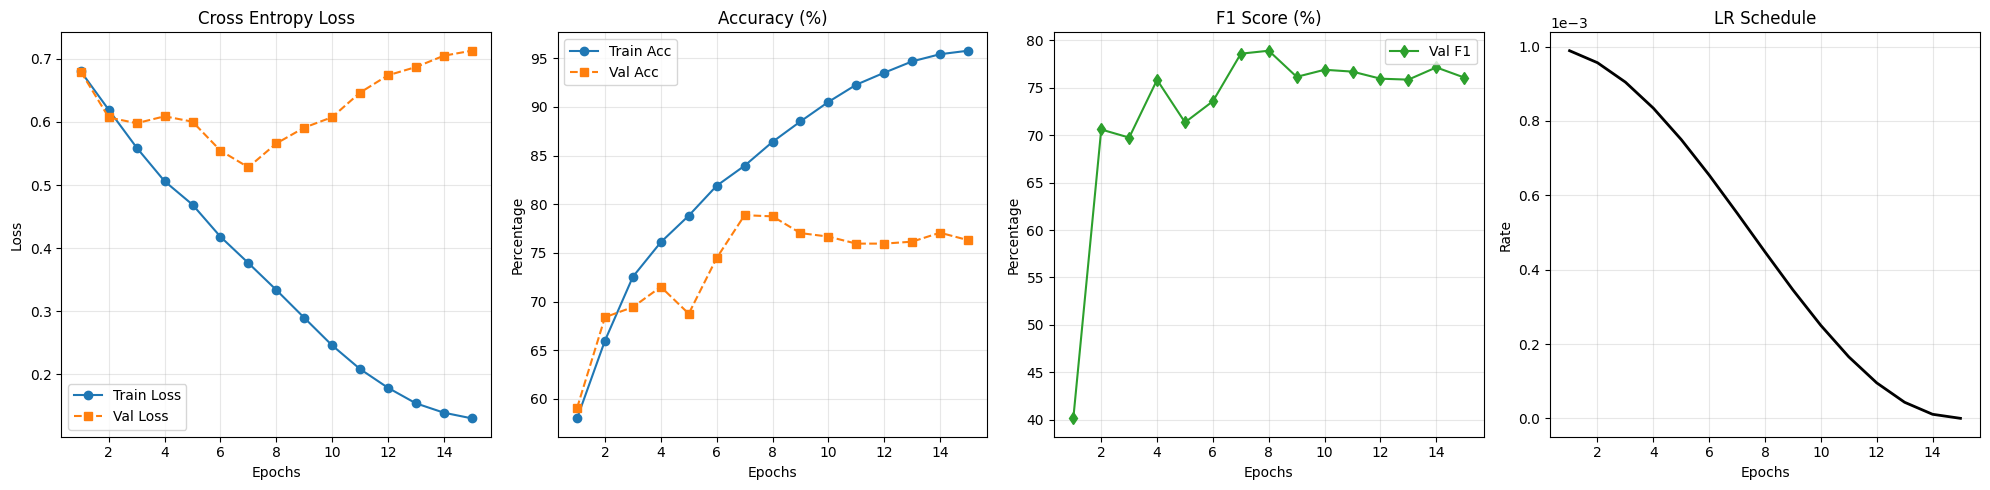

In [17]:
# Visualize & Audit
plot_history(history)


             FINAL TEST SET AUDIT              
Loss: 0.7139 | Accuracy: 75.76% | F1: 75.65%

Classification Report:
               precision    recall  f1-score   support

         neg       0.76      0.76      0.76     12500
         pos       0.76      0.75      0.76     12500

    accuracy                           0.76     25000
   macro avg       0.76      0.76      0.76     25000
weighted avg       0.76      0.76      0.76     25000



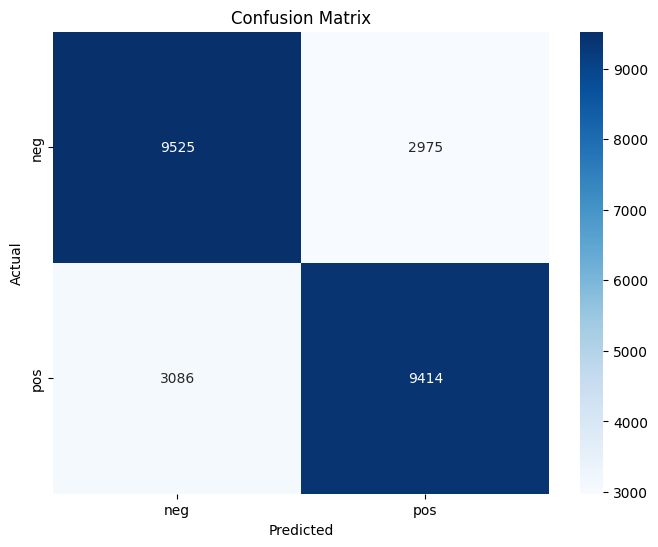


Final Summary | Loss: 0.7139 | Accuracy: 75.76% | F1-score: 75.65%


In [18]:
# --- Final Evaluation (The "Audit") ---
print("\n" + "="*50)
print("             FINAL TEST SET AUDIT              ")
print("="*50)

# We set plot=True here to get the Heatmap and Classification Report
test_loss, test_acc, test_f1 = evaluate_classification(
    model, 
    test_loader, 
    DEVICE, 
    is_binary=IS_BINARY, 
    class_names=class_names,
    plot=True
)

print("="*100)
print(f'\nFinal Summary | Loss: {test_loss:.4f} | Accuracy: {test_acc:.2%} | F1-score: {test_f1:.2%}')
print("="*100)

****---
## 4. Model Inference and Sentiment Prediction

---

In [19]:
tokenizer

<function __main__.<lambda>(text)>

In [20]:
def predict_robust(model, sentence, vocab, tokenizer, class_names, is_binary=False):
    model.eval()

    # Step A: Tokenize exactly like training
    tokens = tokenizer(sentence)
    
    # Step B: Numericalize (Default to <UNK> index 1)
    indexed = [vocab.get(t, 1) for t in tokens]
    
    # Safety: Handle empty or purely non-alphanumeric input
    if len(indexed) == 0:
        return "N/A", 0.0

    # Step C: Prepare Tensors [Batch Size 1, Seq_Len]
    tensor = torch.LongTensor(indexed).unsqueeze(0).to(DEVICE)
    length = torch.LongTensor([len(indexed)]).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor, length)

        if is_binary:
            # --- BINARY MODE (IMDB) ---
            # Flattens [1, 1] to [1] and squashes to 0-1
            prob = torch.sigmoid(logits.view(-1)).item()
            prediction_idx = 1 if prob > 0.5 else 0
            # Confidence is distance from the 0.5 decision boundary
            confidence = prob if prediction_idx == 1 else 1 - prob
        else:
            # --- MULTI-CLASS MODE (AG News, etc.) ---
            # Converts logits to a probability distribution across N classes
            probs = torch.softmax(logits, dim=1)
            prediction_idx = torch.argmax(probs, dim=1).item()
            confidence = probs[0][prediction_idx].item()

    # Map the index back to the human-readable string from metadata
    label = class_names[prediction_idx]
    
    return label, confidence

# ================================================================================
def run_test_suite(model, tests, vocab, tokenizer, class_names, is_binary):
    """
    Runs a batch of tests and prints a professional, formatted report.
    """
    print(f"{'Input Sentence (First 50 chars)':<55} | {'Prediction':<12} | {'Conf'}")
    print("-" * 80)
    
    for text in tests:
        # Our universal prediction function
        label, conf = predict_robust(
            model, text, vocab, tokenizer, class_names, is_binary
        )
        
        # Simple threshold for "High Confidence" (e.g., 80%)
        # In a notebook, this makes identifying weaknesses easy
        marker = "★" if conf > 0.8 else " "
        
        print(f"{text[:50]:<55} | {label:<12} | {conf:>6.1%} {marker}")

In [21]:
# 1. Define the test cases
imdb_tests = [
    "I wanted to like this movie, but the acting was wooden and the plot was a mess.", # Negative
    "An absolute triumph of cinema that I would recommend to everyone I know.",       # Positive
    "Not the worst thing I've ever seen, but definitely not the best either.",       # Leaning Neg
    "The special effects were stunning, though the story felt a bit rushed.",         # Mixed/Positive
    "I fell asleep halfway through; avoid this waste of time at all costs."          # Highly Negative
]

# 2. Run the Suite
print(f"{'Review (First 58 chars)':<60} | {'Sentiment':<12} | {'Confidence'}")
print("-" * 90)

for text in imdb_tests:
    # predict_robust handles the Sigmoid/Binary logic internally
    label, conf = predict_robust(
        model, text, vocab, tokenizer, class_names, is_binary=IS_BINARY
    )
    
    # Visual cue for very strong opinions
    marker = "★" if conf > 0.9 else "  "
    
    print(f"{text[:58]:<60} | {label:<12} | {conf:>6.1%} {marker}")

Review (First 58 chars)                                      | Sentiment    | Confidence
------------------------------------------------------------------------------------------
I wanted to like this movie, but the acting was wooden and   | neg          |  99.8% ★
An absolute triumph of cinema that I would recommend to ev   | pos          |  99.5% ★
Not the worst thing I've ever seen, but definitely not the   | neg          |  91.5% ★
The special effects were stunning, though the story felt a   | pos          |  98.0% ★
I fell asleep halfway through; avoid this waste of time at   | neg          |  99.9% ★


In [22]:
%watermark -iv

datasets   : 4.4.1
matplotlib : 3.10.0
numpy      : 2.0.2
pandas     : 2.2.2
re         : 2.2.1
seaborn    : 0.13.2
sklearn    : 1.6.1
torch      : 2.8.0+cu126
torchinfo  : 1.8.0
torchvision: 0.23.0+cu126

